### Applying Logistic Regression and SVM

Knn on reviews dataset (classifying reviews as positive and negative)

In [6]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("./datasets/reviews.csv")

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["review"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print(pred[:5])


[1 0 0 1 1]


knn on handwritten digits dataset - checking which K has highest accuracy

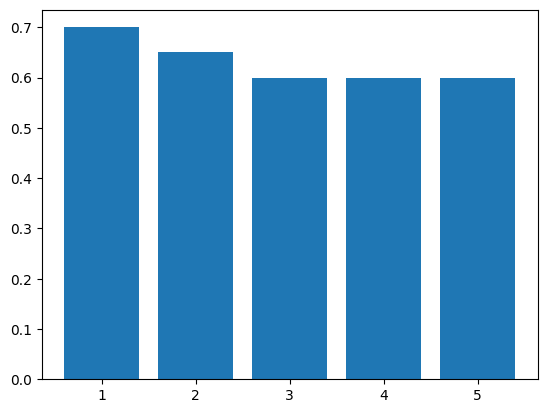

In [4]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,stratify=y, random_state=42)

X_train = X_train[:100]
X_test = X_test[:20]

y_train = y_train[:100]
y_test = y_test[:20]

ks = [1, 2, 3, 4, 5]
scores = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.bar(ks, scores)
plt.show()

Running LogisticRegression and SVC

In [6]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,stratify=y, random_state=42)

# apply logistic regression and print the scores
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
print("Logistic Regression score on Trainning set: ", logreg.score(X_train, y_train))
print("Logistic Regression score on Test set : ", logreg.score(X_test, y_test))

# apply SVC and print the scores
svc = SVC()
svc.fit(X_train, y_train)
print("SVC score on Trainning set: ", svc.score(X_train, y_train))
print("SVC score on Test set: ", svc.score(X_test, y_test))

Logistic Regression score on Trainning set:  1.0
Logistic Regression score on Test set :  0.9583333333333334
SVC score on Trainning set:  0.9979123173277662
SVC score on Test set:  0.9916666666666667


c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Sentiment Analysis for movie reviews

In [19]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression

with open("./datasets/vocabulary.txt", "r") as file:
    vocabulary = file.read().splitlines()

def get_features(reviews):
    features = []
    for review in reviews:
        words = review.lower().split()
        feature = []
        for word in vocabulary:
            if word in words:
                feature.append(1)
            else:
                feature.append(0)
        features.append(feature)
    return features

df = pd.read_csv("./datasets/reviews.csv")
X = np.array(get_features(df["review"].values))
y = df["label"]


lr = LogisticRegression()
lr.fit(X, y)

# Predict sentiment for a glowing review
review1 = "LOVED IT! This movie was amazing. Top 10 this year."
review1_features = get_features([review1])
print("Review:", review1)
print("Probability of positive review:", lr.predict_proba(review1_features)[0,1])

# Predict sentiment for a poor review
review2 = "Total junk! I'll never watch a film by that director again, no matter how good the reviews."
review2_features = get_features([review2])
print("Review:", review2)
print("Probability of positive review:", lr.predict_proba(review2_features)[0,1])


Review: LOVED IT! This movie was amazing. Top 10 this year.
Probability of positive review: 0.5888052012717825
Review: Total junk! I'll never watch a film by that director again, no matter how good the reviews.
Probability of positive review: 0.3289685128686932
